In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import illustris_python as il
import pickle

In [2]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [3]:
snapnum=40

In [4]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200", "Group_R_TopHat200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [118]:
pos = halos["GroupPos"]/1e3

In [119]:
sfr = halos["GroupSFR"]

In [663]:
mask = (mvir > 11) & (mvir < 11.1)

In [664]:
pos1 = pos[mask]

In [122]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [125]:
rvir = halos["Group_R_TopHat200"]

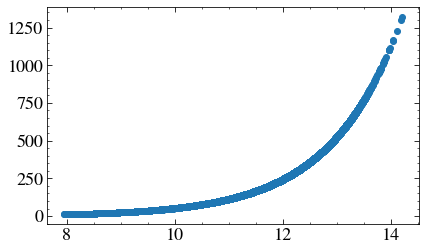

In [28]:
plt.scatter(mvir, rvir, s=1)

In [392]:
mask = (mvir > 11) & (mvir < 11.5)

In [665]:
rvir[mask]

array([120.302864, 120.28086 , 117.66336 , ..., 113.49836 , 114.24715 ,
       113.9166  ], dtype=float32)

In [32]:
np.log10(2*np.pi/(250/1e3))

1.4002398596860774

In [28]:
R = 250/1e3
print(R)

0.25


In [29]:
def result_k(k, R):
    result2 = - 4 * np.pi * (2*R*k*np.cos(2*k*R) - np.sin(2*k*R))/ k**3
    return result2

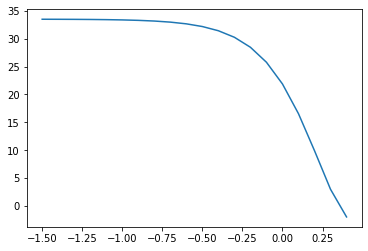

In [195]:
R = 1
plt.plot(logk, result_k(10**logk, R))


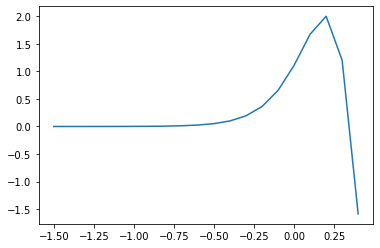

In [196]:
R = 1
plt.plot(logk, coef1*result_k(10**logk, R))


In [ ]:
convolved = np.convolve(fit_nl(logk),result_k(10**logk,R),"same")

In [247]:
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck18')
r_arr = np.arange(0.01, 1, 0.01)
cf = cosmo.correlationFunction(r_arr, z=1.5)

In [419]:
from nbodykit.lab import cosmology as n_cosmology
#c      = n_cosmology.Planck15
#n_cosmology.P_k_max=100
c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [420]:
n_cosmology.P_k_max

100

In [425]:
Pnl(60.)

array(0.0278955)

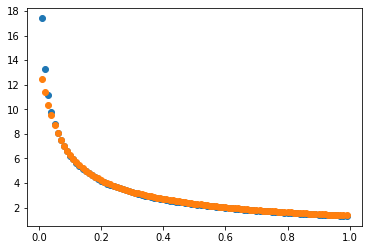

In [252]:
plt.scatter(r_arr, cf)
plt.scatter(r_arr, cf_lin(r_arr))

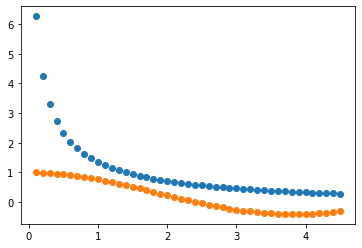

In [254]:
R = 2.3
r = np.arange(0.1, 2*R, 0.1)
xi = cf_lin(r)
j0 = scipy.special.jv(0, r)
plt.scatter(r, xi)
plt.scatter(r,j0)

In [427]:
def kernel(k, R=1, nbins=100):
    r = np.linspace(0, R, nbins)
    xi = cf_lin(r)
    j0 = scipy.special.jv(0, k*r)
    return 4 * np.pi * np.trapz(r**2 * xi * j0, r)

In [426]:
def kernel_nl(k, R=1, nbins=100):
    r = np.linspace(0, R, nbins)
    xi = cf_nl(r)
    j0 = scipy.special.jv(0, k*r)
    return 4 * np.pi * np.trapz(r**2 * xi * j0, r)

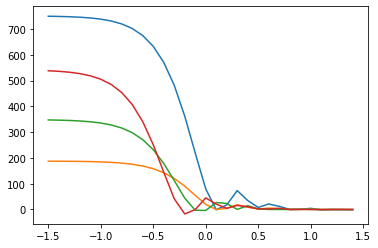

In [435]:
logks = np.arange(-1.5, 1.5, 0.1)

for i, R in enumerate(np.arange(4,8.1, 2)):
    kernels = []
    for logk in logks:
        kernels.append(kernel_nl(10**logk, R=R))
    if i == 0:
        plt.plot(logks, np.array(kernels)*4)
    plt.plot(logks, kernels)
#print(kernel(0.1,1))

In [384]:
odir1 = "../paper1/ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM12-12.5.pickle", "rb") as f:
    Pk_mean12 = pickle.load(f)
    Pk12 = pickle.load(f)
print("shotnoise", Pk12.attrs["shotnoise"])

shotnoise 926.3583221039135


In [386]:
odir1 = "../paper1/ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM11-11.5.pickle", "rb") as f:
    Pk_mean12 = pickle.load(f)
    Pk11 = pickle.load(f)
print("shotnoise", Pk12.attrs["shotnoise"])

shotnoise 926.3583221039135


In [474]:
R = 0.7
kernels_nl = []
for logk in logks:
    kernels_nl.append(kernel_nl(10**logk, R=R))

In [475]:
R = 0.7
kernels_lin = []
for logk in logks:
    kernels_lin.append(kernel(10**logk, R=R))

In [429]:
R = 0.35
kernels_lin = []
for logk in logks:
    kernels_lin.append(kernel(10**logk, R=R))

In [373]:
def W_R(k, R=1):
    return 3 * (np.sin(k*R) - k*R*np.cos(k*R))/(k*R)**3

In [415]:
logks

array([-1.50000000e+00, -1.40000000e+00, -1.30000000e+00, -1.20000000e+00,
       -1.10000000e+00, -1.00000000e+00, -9.00000000e-01, -8.00000000e-01,
       -7.00000000e-01, -6.00000000e-01, -5.00000000e-01, -4.00000000e-01,
       -3.00000000e-01, -2.00000000e-01, -1.00000000e-01,  1.33226763e-15,
        1.00000000e-01,  2.00000000e-01,  3.00000000e-01,  4.00000000e-01,
        5.00000000e-01,  6.00000000e-01,  7.00000000e-01,  8.00000000e-01,
        9.00000000e-01,  1.00000000e+00,  1.10000000e+00,  1.20000000e+00])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in log10
  if __name__ == '__main__':


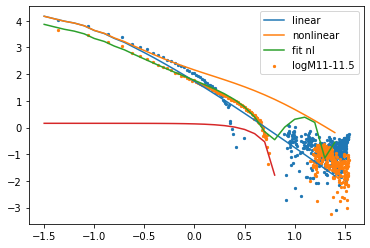

In [440]:
#convolved = np.convolve(fit_pnl(logk),W_R(10**logk),"same")
plt.scatter(np.log10(Pk_sum10["k"]), np.log10(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]), s=5)
plt.plot(logks, np.log10(3*Plin(10**logks)), label="linear")
plt.plot(logks, np.log10(3*Pnl(10**logks)), label="nonlinear")
plt.plot(logks, np.log10(1.5*Pnl(10**logks) - 1.5*np.array(kernels_nl) - ((4*np.pi*R**3)/3)*W_R(10**logks, R)), label="fit nl")
#plt.plot(logks, np.log10(3*Plin(10**logks) - 3*np.array(kernels_lin) - ((4*np.pi*R**3)/3)*W_R(10**logks, R)), label="fit lin")
#plt.scatter(np.log10(Pk12["k"]), np.log10(Pk12["power"].real-Pk12.attrs["shotnoise"]), s=5, label="logM12-12.5")
plt.scatter(np.log10(Pk11["k"]), np.log10(Pk11["power"].real-Pk11.attrs["shotnoise"]), s=5, label="logM11-11.5")
plt.plot(logks,np.log10(((4*np.pi*R**3)/3)*W_R(10**logks, R)))
#plt.ylim(-1,5)
plt.legend()

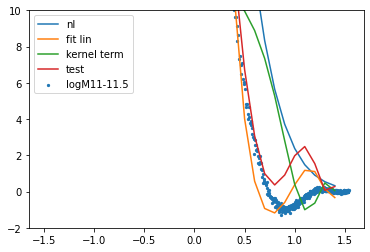

In [472]:
plt.scatter(np.log10(Pk11["k"]),Pk11["power"].real-Pk11.attrs["shotnoise"], s=5, label="logM11-11.5")
plt.plot(logks, 1.5*Pnl(10**logks), label="nl")
#plt.plot(logks, 1.5*Pnl(10**logks) - 1.5*np.array(kernels_nl) - ((4*np.pi*R**3)/3)*W_R(10**logks, R), label="fit nl")
plt.plot(logks, 8*Plin(10**logks) - 8*np.array(kernels_lin) - ((4*np.pi*R**3)/3)*W_R(10**logks, R), label="fit lin")
#plt.scatter(np.log10(Pk12["k"]), np.log10(Pk12["power"].real-Pk12.attrs["shotnoise"]), s=5, label="logM12-12.5")
#plt.plot(logks,((4*np.pi*R**3)/3)*W_R(10**logks, R), label="W_R term")
plt.plot(logks,1.5*np.array(kernels_nl), label="kernel term")
plt.plot(logks, 1.5*Pnl(10**logks) - 1.5*np.array(kernels_nl), label="test")
plt.ylim(-2,10)
plt.legend()

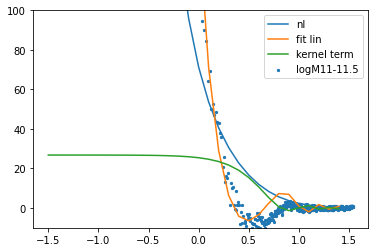

In [487]:
plt.scatter(np.log10(Pk12["k"]),Pk12["power"].real-Pk12.attrs["shotnoise"], s=5, label="logM11-11.5")
plt.plot(logks, 1.5*Pnl(10**logks), label="nl")
#plt.plot(logks, 1.5*Pnl(10**logks) - 1.5*np.array(kernels_nl) - ((4*np.pi*R**3)/3)*W_R(10**logks, R), label="fit nl")
plt.plot(logks, 10*Plin(10**logks) - 10*np.array(kernels_lin) - ((4*np.pi*R**3)/3)*W_R(10**logks, R), label="fit lin")
#plt.scatter(np.log10(Pk12["k"]), np.log10(Pk12["power"].real-Pk12.attrs["shotnoise"]), s=5, label="logM12-12.5")
#plt.plot(logks,((4*np.pi*R**3)/3)*W_R(10**logks, R), label="W_R term")
plt.plot(logks,1.5*np.array(kernels_nl), label="kernel term")
#plt.plot(logks, 1.5*Pnl(10**logks) - 1.5*np.array(kernels_nl), label="test")
plt.ylim(-10,100)
plt.legend()

In [ ]:
def kernel_nl(k, R=1, nbins=100):
        r = np.linspace(0, R, nbins)
        xi = cf_nl(r)
        j0 = scipy.special.jv(0, k*r)
        return 4 * np.pi * np.trapz(r**2 * xi * j0, r)

In [556]:
def kernel_NL(ks, R=1, nbins=100):
    results = []
    r = np.linspace(0, R, nbins)
    xi = cf_nl(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [643]:
def kernel_lin(ks, R=1, nbins=100):
    results = []
    r = np.linspace(0, R, nbins)
    xi = cf_lin(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [644]:
def fit_pow(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, bias=3, R=1):
    result = a + b*(logk-logk0) + c*(logk-logk0)**2 + d*(logk-logk0)**3

    mask = logk < logk0
    result[mask] = a
    
    result = result*bias*Plin(10**logk) - bias*kernel_NL(10**logk, R=R) - ((4*np.pi*R**3)/3)*W_R(10**logk, R)
    
    return result 

In [653]:
def fit_pow2(logk, a=1,logk0=0, bias=3, R=1):
    #result = a + b*(logk-logk0) + c*(logk-logk0)**2 + d*(logk-logk0)**3
    result = np.exp((logk-logk0)/a)
    
    result = result*bias*Plin(10**logk) - bias*kernel_NL(10**logk, R=R) - ((4*np.pi*R**3)/3)*W_R(10**logk, R)
    
    return result 

In [625]:
def fit_pNL(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, bias=3, R=1):
    result = a + b*(logk-logk0) + c*(logk-logk0)**2 + d*(logk-logk0)**3
    mask = logk < logk0
    result[mask] = a
    return result

In [632]:
iend = 100
mask = (np.log10(Pk12["k"]) > -0.5) & ((np.log10(Pk12["k"]) < 1.5))
logk1 = np.log10(Pk12["k"])[mask]
pow1 = (Pk12["power"].real-Pk12.attrs["shotnoise"])[mask]
bias = 3
biased = bias*Plin(10**logk1)

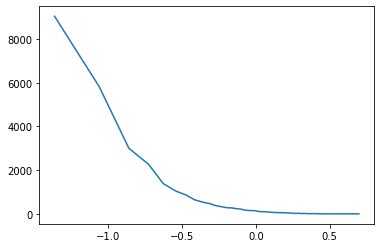

In [542]:
plt.plot(logk1, pow1)

In [648]:
from scipy.optimize import curve_fit
p0 = [1,1,0.01,0.1,-0.5,2.44,1]
bounds=([-2, -2, -2,-2, -0.9, 2.43, 0], [2, 2, 2,5, -0.4, 2.45, 1])
pop_fit, pcov = curve_fit(fit_pow, logk1,pow1,maxfev = 4000,p0=p0, bounds=bounds)

In [ ]:
a=1,logk0=0, bias=3, R=1

In [659]:

p0 = [1,0,2.44,1]
bounds=([0.1, -2,  2.43, 0], [5, 0.5, 2.45, 1])
pop_fit, pcov = curve_fit(fit_pow2, logk1,pow1,maxfev = 4000,p0=p0, bounds=bounds)

In [660]:
pop_fit

array([ 0.81608915, -0.9844833 ,  2.43      ,  0.53121156])

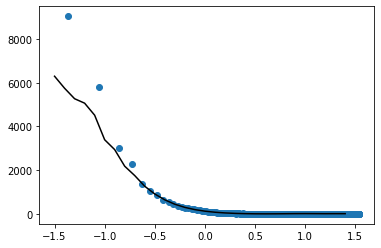

In [662]:
plt.scatter(np.log10(Pk12["k"]), Pk12["power"].real-Pk12.attrs["shotnoise"])
plt.plot(logks, fit_pow2(logks, *pop_fit), c="k")
#plt.ylim(-10,10)

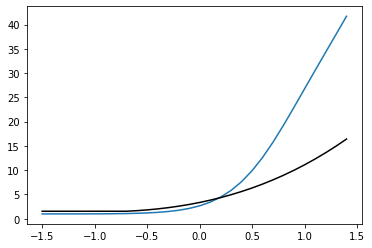

In [630]:
#plt.scatter(np.log10(Pk12["k"]), Pk12["power"].real-Pk12.attrs["shotnoise"])
plt.plot(logks, Pnl(10**logks)/Plin(10**logks))
plt.plot(logks, fit_pNL(logks, *pop_fit), c="k")
#plt.ylim(-10,100)

In [606]:
logk11 = np.log10(Pk11["k"])[mask]
pow11 = (Pk11["power"].real-Pk11.attrs["shotnoise"])[mask]
pop_fit, pcov = curve_fit(fit_pow, logk11,pow11,maxfev = 4000,p0=p0, bounds=bounds)


In [607]:
print(pop_fit)

[ 3.31155891e-01  1.12146220e+00 -2.00000000e+00  1.58648814e+00
 -7.00000000e-01  3.99999912e+00  1.46862860e-07]


(-10.0, 10.0)

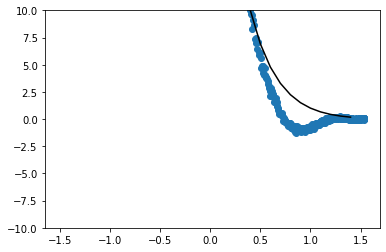

In [609]:
plt.scatter(np.log10(Pk11["k"]), Pk11["power"].real-Pk11.attrs["shotnoise"])
plt.plot(logks, fit_pow(logks, *pop_fit), c="k")
#plt.ylim(-10,10)

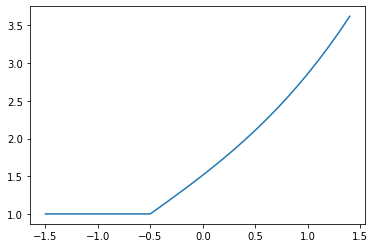

In [530]:
plt.plot(logks, poly(logks))

In [ ]:
plt.scatter(np.log10(Pk12["k"]),Pk12["power"].real-Pk12.attrs["shotnoise"], s=5, label="logM11-11.5")
plt.plot(logks, fit_pow(logks, *pop_fit), label="corrected pk")
plt.plot(logks, 3*poly(logks,c=10)*Plin(10**logks) - 3*np.array(kernels_lin) - ((4*np.pi*R**3)/3)*W_R(10**logks, R), label="fit lin")

plt.ylim(-10,1000)
plt.legend()

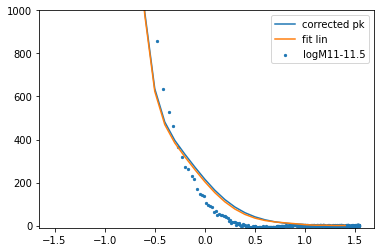

In [531]:
plt.scatter(np.log10(Pk12["k"]),Pk12["power"].real-Pk12.attrs["shotnoise"], s=5, label="logM11-11.5")
plt.plot(logks, 3*poly(logks,c=10)*Plin(10**logks), label="corrected pk")
plt.plot(logks, 3*poly(logks,c=10)*Plin(10**logks) - 3*np.array(kernels_lin) - ((4*np.pi*R**3)/3)*W_R(10**logks, R), label="fit lin")

plt.ylim(-10,1000)
plt.legend()

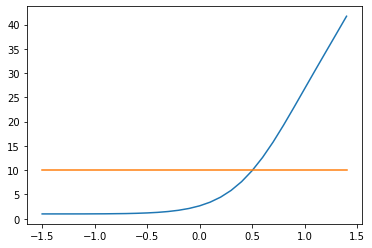

In [486]:
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="nl")
plt.plot(logks, [10]*len(logks), label="nl")

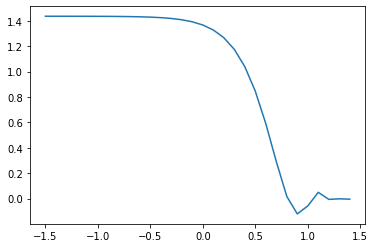

In [439]:
plt.plot(logks,((4*np.pi*R**3)/3)*W_R(10**logks, R))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in log10
  """Entry point for launching an IPython kernel.


(1.0, 5.0)

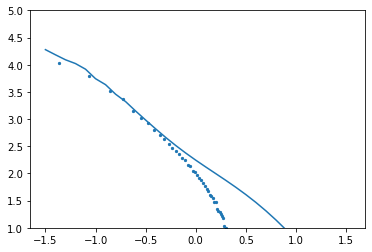

In [382]:
plt.scatter(np.log10(Pk_sum10["k"]), np.log10(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]), s=5)
plt.plot(logks, np.log10(4*Pnl(10**logks)), label="nonlinear")
plt.ylim(1,5)

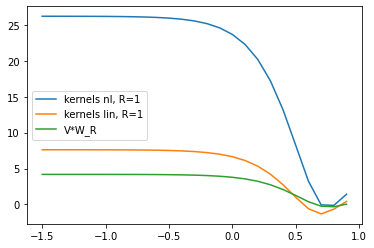

In [364]:

plt.plot(logks, np.array(kernels_nl), label=f"kernels nl, R={R}")

plt.plot(logks, np.array(kernels_lin), label=f"kernels lin, R={R}")
plt.plot(logks,((4*np.pi*R**3)/3)*W_R(10**logks, R), label="V*W_R")
plt.legend()

In [30]:
logk = np.arange(-1.5, 1.5, 0.1)

In [31]:
k = 10**logk

In [32]:

odir = "ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sum_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)
print("shotnoise", Pk_sum10.attrs["shotnoise"])

shotnoise 304.0903879154701


Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

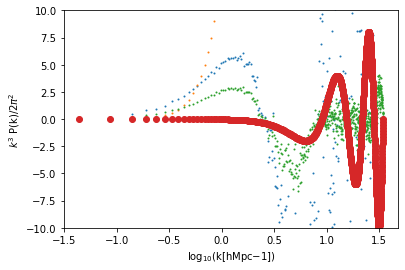

In [40]:
k_tng =Pk_sum10["k"]
coef = k_tng**3/(2*np.pi**2)
plt.scatter(np.log10(Pk_sum10["k"]), coef*(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]), s=1)

plt.scatter(np.log10(Pk_sum10["k"]), coef*(Pk_sum10.attrs["shotnoise"]), s=1)

plt.scatter(np.log10(k_tng), -coef*result_k(k_tng, R))
plt.ylim(-10,10)
plt.ylabel(r"$k^3$ P(k)/2$\pi^2$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

(-1.0, 10.0)

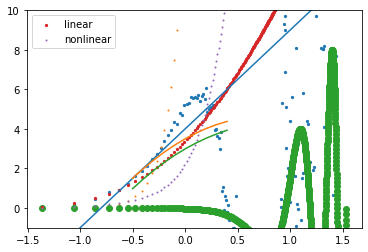

In [168]:
k_tng =Pk_sum10["k"]
coef = k_tng**3/(2*np.pi**2)
plt.scatter(np.log10(Pk_sum10["k"]), coef*(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]), s=5)

plt.scatter(np.log10(Pk_sum10["k"]), coef*(Pk_sum10.attrs["shotnoise"]), s=1)

plt.scatter(np.log10(k_tng), -coef*result_k(k_tng, R))

from nbodykit import cosmology

cosmo1 = cosmology.Planck15
z=1.5
Plin = cosmology.LinearPower(cosmo1, redshift=z, transfer='EisensteinHu') 
Pk_linear = Plin(k_tng)
plt.scatter(np.log10(Pk_sum10["k"]), 4*coef*(Pk_linear), s=5, label="linear")

convolved = np.convolve(Pk_linear,result_k(k_tng,R),"same")
#plt.scatter(np.log10(Pk_sum10["k"]),convolved)

Pnl = cosmology.power.halofit.HalofitPower(cosmo1, redshift=z) 
Pk_nonlinear = Pnl(k_tng[:100])
plt.scatter(np.log10(Pk_sum10["k"][:100]), coef[:100]*(Pk_nonlinear), s=1, label="nonlinear")
plt.plot(np.log10(Pk_sum10["k"]), 5*np.log10(Pk_sum10["k"]/10**-0.5)+1.5)
#convolved = np.convolve(Pk_nonlinear,result_k(k_tng[:100],R),"same")
#plt.scatter(np.log10(Pk_sum10["k"][:100]),-coef[:100]*4*convolved)
plt.plot(logk, fit_nl(logk))
plt.plot(logk, fit_nl(logk)-result_k(10**logk,R))
plt.legend()
plt.ylim(-1,10)

In [177]:
logk = np.arange(-1.5,0.5,0.1)

In [214]:
def fit_pnl(logk, a=3, b=-1, c=-1, logk0=-0.5):
    return 10**(a + b*(logk-logk0) + c*(logk-logk0)**2)
    

In [198]:
coef1 = (10**logk)**3/(2*np.pi**2)

In [190]:
convolved = np.convolve(fit_nl(logk),coef1*result_k(10**logk,R),"same")

In [234]:
def W_R(k, R=1):
    #return 3 * (np.sin(k*R) - k*R*np.cos(k*R))/(k*R)**3
    #return np.zeros(len(k)) + 1

In [227]:
convolved = np.convolve(fit_pnl(logk),W_R(10**logk),"same")

In [239]:
convolved = np.convolve(fit_pnl(logk),W_R(10**logk)*(10**logk)**2,"same")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in log10
  


(-1.0, 5.0)

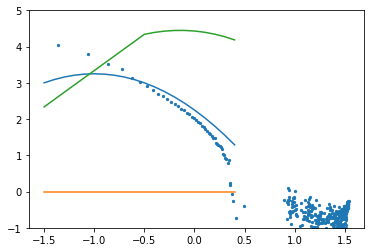

In [240]:
#convolved = np.convolve(fit_pnl(logk),W_R(10**logk),"same")
plt.scatter(np.log10(Pk_sum10["k"]), np.log10(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]), s=5)
plt.plot(logk, np.log10(fit_pnl(logk)))
plt.plot(logk, np.log10(W_R(10**logk)))
plt.plot(logk, np.log10(convolved))
plt.ylim(-1,5)

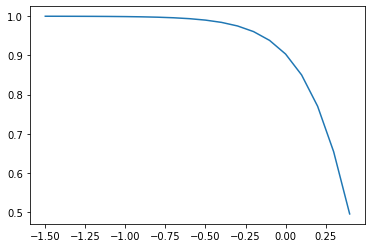

In [231]:
plt.plot(logk, W_R(10**logk))

In [224]:

correlationFunction

(-1.0, 1.0)

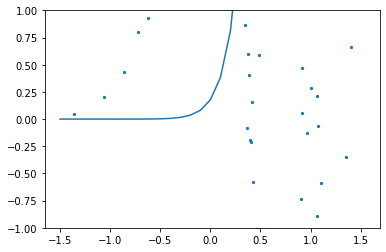

In [201]:
plt.scatter(np.log10(Pk_sum10["k"]), coef*(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]), s=5)
plt.plot(logk, fit_nl(logk)*(10**logk)**3/(2*np.pi**2))
plt.ylim(-1,1)

No handles with labels found to put in legend.


(-1.0, 1.0)

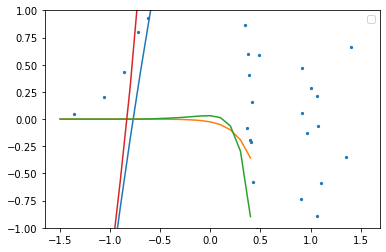

In [193]:
plt.scatter(np.log10(Pk_sum10["k"]), coef*(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]), s=5)

#plt.plot(logk, fit_nl(logk))
plt.plot(logk, fit_nl(logk)-coef1*result_k(10**logk,R))
plt.plot(logk, -coef1*result_k(10**logk,R))
plt.plot(logk, -coef1*convolved)
plt.plot(logk, fit_nl(logk)-coef1*result_k(10**logk,R) - convolved)
plt.legend()
plt.ylim(-1,1)

In [50]:
def pk_c(k, exp_param):
    pk = k**exp_param
    
    return pk
    

def total_pk(k, exp_param):
    R_parameter = 0.25
    coef = k**3/(2*np.pi**2)
    pk_tot = pk_c(k, exp_param) - result_k(k,R_parameter) - np.convolve(pk_c(k, exp_param), result_k(k,R_parameter), "same")
    coef*pk_tot
    return pk_tot

In [70]:
import scipy
istart = 6
iend=100

exp, err = scipy.optimize.curve_fit(total_pk, Pk_sum10["k"][istart:iend], (Pk_sum10["k"][istart:iend]**3/(2*np.pi**2))*(Pk_sum10["power"].real[istart:iend]-Pk_sum10.attrs["shotnoise"]))
exp, err

(array([-1.31032289]), array([[0.17918138]]))

In [68]:
np.log10(k_tng[istart:iend])

array([-0.473019  , -0.41424163, -0.36117288, -0.31354678, -0.27102314,
       -0.23226579, -0.19665425, -0.16393475, -0.13327703, -0.10463917,
       -0.07807909, -0.05288839, -0.02885982, -0.00633747,  0.01517543,
        0.03567356,  0.05510273,  0.07391712,  0.09187437,  0.10904308,
        0.12551484,  0.14142312,  0.15695358,  0.17190578,  0.18620873,
        0.20013114,  0.21361958,  0.22663389,  0.23935564,  0.25168748,
        0.26367238,  0.27536633,  0.28672129,  0.29780559,  0.30861199,
        0.31914721,  0.32947148,  0.33949434,  0.34928066,  0.35891702,
        0.36829864,  0.37750718,  0.38653877,  0.39535522,  0.4040084 ,
        0.41250792,  0.42084111,  0.42898897,  0.43696645,  0.44482085,
        0.45257068,  0.46019204,  0.46765594,  0.47497178,  0.48217729,
        0.48929016,  0.49628311,  0.50313165,  0.5098912 ,  0.51656004,
        0.52310279,  0.52957073,  0.53594125,  0.54221343,  0.548415  ,
        0.55450724,  0.56051092,  0.56644747,  0.57230217,  0.57

(-10.0, 10.0)

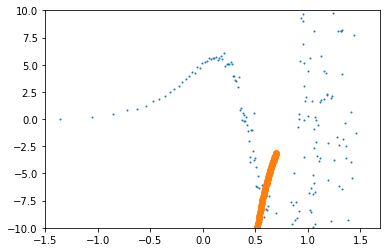

In [69]:
plt.scatter(np.log10(Pk_sum10["k"]), coef*(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]), s=1)

plt.scatter(np.log10(k_tng[istart:iend]), total_pk(k_tng[istart:iend], exp))
plt.ylim(-10,10)

In [144]:
from Corrfunc.theory import xi

rmin = 0.01
rmax = 5.0
nbins = 100
boxsize = 205
bins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1)
results = xi(boxsize, 2, bins , pos1[:,0],pos1[:,1],pos1[:,2], 
             weights=None,output_ravg=True)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


(-1.0, 50.0)

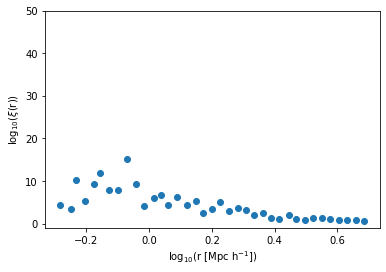

In [145]:
plt.scatter(np.log10(results["ravg"]), results["xi"])
plt.xlabel("log$_{10}$(r [Mpc h$^{-1}$])")
plt.ylabel(r"log$_{10}$($\xi$(r))")
plt.ylim(-1,50)


Text(0, 0.5, '($\\xi$(r))')

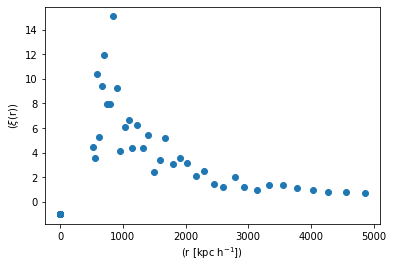

In [146]:
plt.scatter(results["ravg"]*1e3, results["xi"])
plt.xlabel("(r [kpc h$^{-1}$])")
plt.ylabel(r"($\xi$(r))")
#plt.ylim(-1,50)
#plt.xlim(0,1000)


In [138]:
R = 0.25
sigma = 0.09
r = np.arange(0, 1000)
y = 0.5*(1+scipy.special.erf(np.log10(r/R)/(np.sqrt(2)*sigma)))*(clus + 1) - 1

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


NameError: name 'clus' is not defined

(0.0, 1000.0)

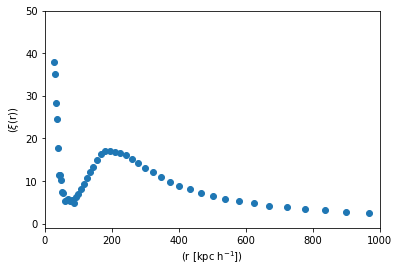

In [42]:
plt.scatter(results["ravg"]*1e3, results["xi"])
plt.xlabel("(r [kpc h$^{-1}$])")
plt.ylabel(r"($\xi$(r))")
plt.ylim(-1,50)
plt.xlim(0,1000)


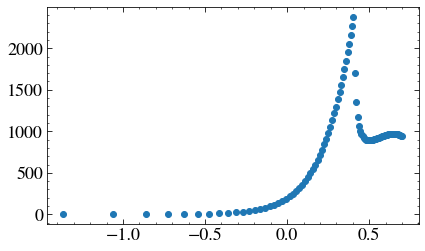

In [109]:
plt.scatter(np.log10(Pk_sum10["k"][:100]),coef[:100]*convolved)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in log10
  


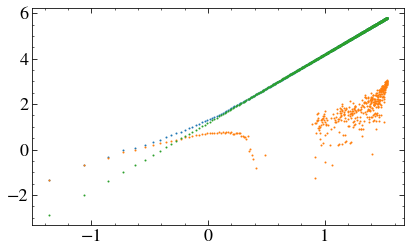

In [83]:
plt.scatter(np.log10(Pk_sum10["k"]), np.log10(coef*(Pk_sum10["power"].real)), s=1)
plt.scatter(np.log10(Pk_sum10["k"]), np.log10(coef*(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), s=1)

plt.scatter(np.log10(Pk_sum10["k"]), np.log10(coef*(Pk_sum10.attrs["shotnoise"])), s=1)

In [ ]:
k_tng =Pk_gal10["k"]
coef = k_tng**3/(2*np.pi**2)
plt.scatter(np.log10(Pk_sum10["k"]), coef*(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]), s=1)

plt.scatter(np.log10(k_tng), coef*result_k(k_tng, R))
plt.ylim(-10,10)

In [ ]:
tan(2Rk) = 2Rk